In [71]:
# ==========================================================
# FIT5201 — Assignment 1 | Section 2: Ridge Regression
# Author: Rishabh Ray (34525416)
# ==========================================================

## Derivation of the SGD Update Rule for Ridge Regression

Our goal is to derive the weight update rule for Stochastic Gradient Descent (SGD) applied to linear regression with L2 regularization (Ridge Regression).

### 1. The Regularized Error Function

First, we define the model's prediction (hypothesis) and the error function for a **single** data sample $(\mathbf{x}^{(i)}, y^{(i)})$, which is what SGD uses at each step.

The hypothesis is:
$$h_{\mathbf{w}}(\mathbf{x}^{(i)}) = \mathbf{w}^T \mathbf{x}^{(i)}$$

The regularized error function $J^{(i)}(\mathbf{w})$ for this single sample is the sum of the squared error and the L2 regularization term:
$$J^{(i)}(\mathbf{w}) = \frac{1}{2} (h_{\mathbf{w}}(\mathbf{x}^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2} ||\mathbf{w}||_2^2$$
where $||\mathbf{w}||_2^2 = \sum_{k=0}^{d} w_k^2$ and $\lambda$ is the regularization strength. The $\frac{1}{2}$ factors are added for mathematical convenience to simplify the derivative.

### 2. Gradient Calculation

Next, we find the gradient of the error function with respect to a single weight $w_j$. This is the partial derivative $\frac{\partial J^{(i)}}{\partial w_j}$.

$$\frac{\partial J^{(i)}}{\partial w_j} = \frac{\partial}{\partial w_j} \left[ \frac{1}{2} (\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)})^2 + \frac{\lambda}{2} \sum_{k=0}^{d} w_k^2 \right]$$

We can differentiate each part of the sum separately:

**A. Derivative of the Error Term:**
We use the chain rule:
$$\frac{\partial}{\partial w_j} \left[ \frac{1}{2} (\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)})^2 \right] = \frac{1}{2} \cdot 2 (\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)}) \cdot \frac{\partial}{\partial w_j}(\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)})$$
Since $\mathbf{w}^T \mathbf{x}^{(i)} = \sum_{k=0}^{d} w_k x_k^{(i)}$, its derivative with respect to $w_j$ is simply $x_j^{(i)}$. This gives us:
$$= (\mathbf{w}^T \mathbf{x}^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$

**B. Derivative of the Regularization Term:**
$$\frac{\partial}{\partial w_j} \left[ \frac{\lambda}{2} \sum_{k=0}^{d} w_k^2 \right] = \frac{\lambda}{2} \cdot (2w_j) = \lambda w_j$$

**Combining both parts**, we get the complete gradient for $w_j$:
$$\frac{\partial J^{(i)}}{\partial w_j} = (h_{\mathbf{w}}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} + \lambda w_j$$

### 3. The SGD Update Rule

The SGD update rule moves the weight in the direction opposite to the gradient, scaled by the learning rate $\eta$.

$$w_j \leftarrow w_j - \eta \frac{\partial J^{(i)}}{\partial w_j}$$

Substituting our derived gradient, we arrive at the final update rule for a single weight $w_j$:
$$\boxed{w_j \leftarrow w_j - \eta \left( (h_{\mathbf{w}}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} + \lambda w_j \right)}$$
This update is performed for each weight in the vector $\mathbf{w}$ using a single, randomly selected data point at each step.

In [74]:
# ==========================================================
# Q4 — Ridge Regression (SGD implementation for L2-regularised linear regression)
# ----------------------------------------------------------
# I follow Module 2 Activity 2.1 and add an L2 penalty. This class does mini-batch SGD
# on J(w) = (1/N)||y - Xw||^2 + λ||w||^2, with optional no-penalty on the bias column.
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

class RidgeSGD:
    """
    Ridge regression via mini-batch SGD.
    Objective: J = (1/N)||y - Xw||^2 + lam||w||^2
    Update: w <- w - eta * [ (2/m) X_B^T (X_B w - y_B) + 2*lam*w ]
    Simple, activity-style implementation (Module 2 Activity 2.1 → add L2).
    """
    def __init__(self, lam=1e-3, lr=1e-2, batch_size=32, epochs=200, shuffle=True, penalize_bias=False, random_state=0):
        # Store hyperparameters: λ, learning rate, batch size, epochs, shuffling, bias penalty, seed.
        self.lam = float(lam)
        self.lr  = float(lr)
        self.batch_size = int(batch_size)
        self.epochs = int(epochs)
        self.shuffle = bool(shuffle)
        self.penalize_bias = bool(penalize_bias)
        self.random_state = int(random_state)
        self.w_ = None  # weights will be learned in fit()

    def fit(self, X, y):
        # Ensure NumPy arrays and 1-D targets; record sample count N and feature dim d.
        X = np.asarray(X, float); y = np.asarray(y, float).ravel()
        N, d = X.shape
        rng = np.random.default_rng(self.random_state)

        # Initialise weights with small Gaussian noise (keeps symmetry broken).
        self.w_ = rng.normal(0, 1e-3, size=d)

        # Build penalty mask P: zero out bias penalty if first column is all ones and penalize_bias=False.
        P = np.ones(d)
        if not self.penalize_bias and np.allclose(X[:, 0], 1.0):
            P[0] = 0.0

        # Epoch loop: shuffle indices each epoch if requested.
        for _ in range(self.epochs):
            idx = np.arange(N)
            if self.shuffle:
                rng.shuffle(idx)

            # Mini-batch loop over shuffled indices.
            for s in range(0, N, self.batch_size):
                B = idx[s:s+self.batch_size]       # batch indices
                XB, yB = X[B], y[B]               # batch data
                m = len(B)                        # batch size (last batch may be smaller)

                # Residuals r_B = X_B w - y_B.
                rB = XB @ self.w_ - yB

                # Gradient: data term (2/m) X_B^T r_B + L2 term 2λ (P ⊙ w).
                grad = (2.0/m) * (XB.T @ rB) + 2.0*self.lam*(P * self.w_)

                # SGD update: w ← w − η * grad.
                self.w_ -= self.lr * grad
        return self

    def predict(self, X):
        # Accept a single sample or a matrix; return linear predictions Xw.
        X = np.asarray(X, float)
        if X.ndim == 1: X = X.reshape(1, -1)
        return X @ self.w_

In [76]:
# ==========================================================
# Q4 — Ridge Regression: quick sanity check on toy linear data
# ----------------------------------------------------------
# I generate a 1D linear dataset with a bias column, fit RidgeSGD,
# then verify MSE is small and weights recover the ground truth.
# ==========================================================

def mse(y_true, y_pred):
    # Standard MSE helper so I can quickly score fits.
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    return float(np.mean((y_true - y_pred)**2))

# Reproducible toy data (simple y = 0.5 + (-1.2)*x + noise).
rng = np.random.default_rng(1)
N = 120
x = rng.uniform(-1, 1, size=N)

# Design matrix with explicit bias column (matches Module 2 activities).
X = np.c_[np.ones(N), x]
w_true = np.array([0.5, -1.2])

# Targets with small Gaussian noise to mimic measurement error.
y = X @ w_true + rng.normal(0, 0.1, size=N)

# Fit my RidgeSGD. I don’t penalise the bias since col 0 is all ones.
model = RidgeSGD(
    lam=1e-2, lr=5e-2, batch_size=32, epochs=300,
    penalize_bias=False, random_state=0
).fit(X, y)

# Report training MSE and learned weights; should be close to w_true.
print("MSE:", f"{mse(y, model.predict(X)):.4f}")
print("w_hat:", model.w_)

MSE: 0.0100
w_hat: [ 0.483481   -1.14861283]


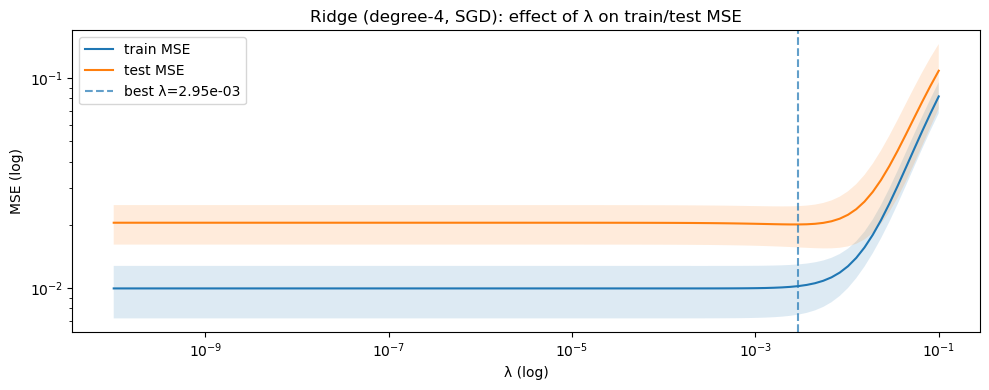

=== Q4.III Summary ===
Repetitions (outer): 10   Train size per rep: 20   Poly degree: 4
λ grid: 1.0e-10 … 1.0e-01  (n=101)
Best λ by mean test MSE: 2.951e-03
Mean train MSE @ λ*: 0.0102  ± 0.0027
Mean  test MSE @ λ*: 0.0201  ± 0.0045
Mean ||w||₂ @ λ*: 1.8062

λ snapshot (mean±std MSE):
  λ=1.000e-10 | train 0.0100±0.0028 | test 0.0205±0.0044 | ||w||₂ 1.8574
  λ=1.778e-08 | train 0.0100±0.0028 | test 0.0205±0.0044 | ||w||₂ 1.8574
  λ=3.162e-06 | train 0.0100±0.0028 | test 0.0205±0.0044 | ||w||₂ 1.8574
  λ=2.951e-03 | train 0.0102±0.0027 | test 0.0201±0.0045 | ||w||₂ 1.8062
  λ=1.000e-01 | train 0.0818±0.0138 | test 0.1084±0.0368 | ||w||₂ 1.1067

Interpretation hints:
- Small λ: low train MSE, higher test MSE → overfitting; ||w||₂ is large (complex model).
- Large λ: both MSEs high → underfitting; ||w||₂ is small (strong shrinkage).
- Middle λ: lowest test MSE (bias–variance balance).


In [78]:
# ==========================================================
# Q4.III(a–c) — Degree-4 poly + Ridge(SGD), 10 reps, shared train set per rep, log–log MSE plots
# ----------------------------------------------------------
# Generate synthetic data (Activity 2.3), build a pipeline
#   Poly(deg=4) → Standardise (ignore bias) → RidgeSGD,
# sweep λ ∈ [1e-10, 1e-1] over 10 repetitions with the SAME train set per rep,
# and plot log λ vs log MSE (train/test) to discuss under/overfitting.
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Synthetic generator (Activity 2.3) ---
def sample_synth(N, rng):
    # Nonlinear target: 0.5*sin(2πx) + 3x + Gaussian noise, x ~ U(-0.6, 0.6)
    x = rng.uniform(-0.6, 0.6, size=N)
    y = 0.5*np.sin(2*np.pi*x) + 3.0*x + rng.normal(0.0, 0.1, size=N)
    return x.reshape(-1,1), y

# --- PolynomialFeatures (no cross-terms) ---
class PolynomialFeatures:
    def __init__(self, degree=4, include_bias=True):
        # Match assignment: degree-4 basis, optional bias column at col 0
        self.degree=int(degree); self.include_bias=bool(include_bias)
    def fit(self, X): 
        # Stateless transformer; included for pipeline consistency
        return self
    def transform(self, X):
        # Build [1, x, x^2, x^3, x^4] for each feature (here 1-D x)
        X = np.asarray(X, float)
        if X.ndim==1: X=X.reshape(-1,1)
        cols = [np.ones((X.shape[0],1))] if self.include_bias else []
        for j in range(X.shape[1]):
            xj = X[:, [j]]
            for d in range(1, self.degree+1):
                cols.append(xj**d)
        return np.hstack(cols)

# --- Scaler that ignores bias column if present ---
class StandardScalerNoBias:
    def fit(self, X):
        # Compute mean/std for non-bias columns only; guard std=0
        X = np.asarray(X, float)
        self.has_bias_ = (X.ndim==2 and np.allclose(X[:,0], 1.0))
        s = 1 if self.has_bias_ else 0
        M = X[:, s:]
        self.mean_ = M.mean(axis=0)
        self.std_  = M.std(axis=0, ddof=0)
        self.std_[self.std_==0] = 1.0
        return self
    def transform(self, X):
        # Standardise non-bias features with stored stats; keep bias as is
        X = np.asarray(X, float).copy()
        s = 1 if (self.has_bias_ and np.allclose(X[:,0], 1.0)) else 0
        X[:, s:] = (X[:, s:] - self.mean_) / self.std_
        return X

# ---- RidgeSGD must be defined above (from Q4.II) ----
# class RidgeSGD(...): uses lam, lr, batch_size, epochs, penalize_bias=False

def mse(y, yhat):
    # MSE helper for compact scoring
    y = np.asarray(y, float).ravel(); yhat = np.asarray(yhat, float).ravel()
    return float(np.mean((y - yhat)**2))

# --- Fixed large test set (reuse for all fits to approximate generalisation error) ---
rng_global = np.random.default_rng(1)
X_test, y_test = sample_synth(5000, rng_global)

# --- Lambda grid: 10^{-10} ... 10^{-1} (101 points, as required) ---
lams = np.geomspace(10**-10, 0.1, 101, endpoint=True)

# --- Experiment settings per brief: 10 repetitions, train size = 20, degree = 4 ---
R = 10
N_tr = 20
deg = 4

# Storage for per-repetition results and a weight-norm proxy for complexity
mse_tr = np.zeros((R, len(lams)))
mse_te = np.zeros((R, len(lams)))
w_norm = np.zeros((R, len(lams)))   # ||w||_2 indicates shrinkage strength

for r in range(R):
    # New train set per repetition; all λ share this SAME train set (variance reduction)
    rng = np.random.default_rng(10_000 + r)
    X_tr, y_tr = sample_synth(N_tr, rng)

    # Pipeline: Φ = Poly(deg=4) → scale(non-bias) → RidgeSGD
    pf = PolynomialFeatures(degree=deg, include_bias=True).fit(X_tr)
    Phi_tr = pf.transform(X_tr)
    Phi_te = pf.transform(X_test)

    scaler = StandardScalerNoBias().fit(Phi_tr)
    Phi_tr_s = scaler.transform(Phi_tr)
    Phi_te_s = scaler.transform(Phi_te)

    for j, lam in enumerate(lams):
        # Train ridge with given λ; no bias penalty to mirror bias column convention
        model = RidgeSGD(lam=lam, lr=0.05, batch_size=min(16, N_tr),
                         epochs=600, shuffle=True, penalize_bias=False,
                         random_state=0).fit(Phi_tr_s, y_tr)
        # Record train/test MSE and weight norm for analysis
        yhat_tr = model.predict(Phi_tr_s)
        yhat_te = model.predict(Phi_te_s)
        mse_tr[r, j] = mse(y_tr, yhat_tr)
        mse_te[r, j] = mse(y_test, yhat_te)
        w_norm[r, j] = float(np.linalg.norm(model.w_))

# --- Aggregate across repetitions (mean ± std) ---
tr_mean, tr_std = mse_tr.mean(axis=0), mse_tr.std(axis=0)
te_mean, te_std = mse_te.mean(axis=0), mse_te.std(axis=0)
wn_mean = w_norm.mean(axis=0)

# --- Select λ* that minimises mean test MSE (our best regularisation strength) ---
j_best = int(np.argmin(te_mean))
lam_star = float(lams[j_best])

# --- Plot: log λ vs log MSE with mean ± std bands (training vs testing) ---
plt.figure(figsize=(10,4))
plt.xscale("log"); plt.yscale("log")
plt.plot(lams, tr_mean, label="train MSE")
plt.plot(lams, te_mean, label="test MSE")
plt.fill_between(lams, np.maximum(tr_mean-tr_std, 1e-12), tr_mean+tr_std, alpha=0.15)
plt.fill_between(lams, np.maximum(te_mean-te_std, 1e-12), te_mean+te_std, alpha=0.15)
plt.axvline(lam_star, ls="--", alpha=0.7, label=f"best λ={lam_star:.2e}")
plt.xlabel("λ (log)"); plt.ylabel("MSE (log)")
plt.title("Ridge (degree-4, SGD): effect of λ on train/test MSE")
plt.legend(); plt.tight_layout(); plt.show()

# --- Text summary to support (a–c): overfit/underfit regions and best λ ---
ratio = te_mean / np.maximum(tr_mean, 1e-12)        # generalisation gap proxy
overfit_region = lams[ratio > 1.5]                   # heuristic: test >> train → overfitting
underfit_region = lams[(tr_mean > tr_mean.min()*3) & (te_mean > te_mean.min()*3)]  # both high

print("=== Q4.III Summary ===")
print(f"Repetitions (outer): {R}   Train size per rep: {N_tr}   Poly degree: {deg}")
print(f"λ grid: {lams[0]:.1e} … {lams[-1]:.1e}  (n={len(lams)})")
print(f"Best λ by mean test MSE: {lam_star:.3e}")
print(f"Mean train MSE @ λ*: {tr_mean[j_best]:.4f}  ± {tr_std[j_best]:.4f}")
print(f"Mean  test MSE @ λ*: {te_mean[j_best]:.4f}  ± {te_std[j_best]:.4f}")
print(f"Mean ||w||₂ @ λ*: {wn_mean[j_best]:.4f}")

# Small snapshot table to discuss curve shape at representative λ
ix = [0, max(1, len(lams)//4), j_best, max(0, len(lams)//2), len(lams)-1]
ix = sorted(set(ix))
print("\nλ snapshot (mean±std MSE):")
for k in ix:
    print(f"  λ={lams[k]:.3e} | train {tr_mean[k]:.4f}±{tr_std[k]:.4f} | test {te_mean[k]:.4f}±{te_std[k]:.4f} | ||w||₂ {wn_mean[k]:.4f}")

# Brief interpretation bullets to paste into the markdown answer for (a–c)
print("\nInterpretation hints:")
print("- Small λ: low train MSE, higher test MSE → overfitting; ||w||₂ is large (complex model).")
print("- Large λ: both MSEs high → underfitting; ||w||₂ is small (strong shrinkage).")
print("- Middle λ: lowest test MSE (bias–variance balance).")


### Q4.IV — Ridge vs Lasso with Correlated Features

If the dataset contains **highly correlated features**, **Ridge Regression** is generally more appropriate.  
- Ridge uses an L2 penalty, which shrinks the coefficients of correlated variables **together**.  
- This stabilises the solution and reduces variance without arbitrarily dropping variables.  
- As a result, Ridge is more reliable when predictors are strongly collinear.

However, if **interpretability** is the top priority, then **Lasso Regression** is preferable.  
- Lasso uses an L1 penalty, which encourages **sparsity** by driving some coefficients exactly to zero.  
- This effectively performs feature selection, leaving only a subset of variables in the final model.  
- A sparser model is easier for humans to interpret, even if it may be less stable with correlated features.

**Summary:**  
- For predictive stability with correlated features → **Ridge**.  
- For human interpretability and feature selection → **Lasso**.